In [1]:
# =============================================
# IMPORTS
# =============================================
import os
import sys
import math

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'✓ Device: {device}')
print(f'✓ PyTorch: {torch.__version__}')

_nb_dir = os.path.abspath('')
if os.path.basename(_nb_dir) in ('experiments', 'examples', 'train'):
    os.chdir(os.path.dirname(_nb_dir))
sys.path.insert(0, os.path.join(os.getcwd(), 'PFNs'))
print(f'✓ Working directory: {os.getcwd()}')

from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig
from pfns.priors.fast_gp import get_batch as get_batch_for_gp

print('✓ PFNs loaded')


✓ Device: mps
✓ PyTorch: 2.10.0
✓ Working directory: /Users/ruslanguliev/VU_RG


✓ PFNs načteny


In [2]:
# =============================================
# MODEL LOADING - helper function
# =============================================
# IMPORTANT: get_batch_for_gp_random_hps must be defined BEFORE torch.load

def get_batch_for_gp_random_hps(batch_size, seq_len, num_features,
                                  device='cpu', hyperparameters=None, **kwargs):
    hps = {'lengthscale': 0.3, 'outputscale': 0.1, 'noise': 1.0}
    return get_batch_for_gp(batch_size, seq_len, num_features,
                             device=device, hyperparameters=hps, **kwargs)


def load_for_inference(checkpoint_path, device='cpu'):
    """
    Loads a PFN checkpoint for inference.
    Supports the new format (key 'priors') and the old format (key 'num_features').
    """
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    config = checkpoint['config']

    if 'num_features' in config:
        num_features     = config['num_features']
        max_dataset_size = config['max_dataset_size']
        criterion        = checkpoint['criterion']
        borders          = criterion.borders.tolist()
        nlayers          = config.get('nlayers', 6)
        # If the config contains fixed HPs (old format), use them directly with get_batch_for_gp.
        # Otherwise (new models with a random HP distribution, no 'hps' key) use
        # get_batch_for_gp_random_hps, which supplies valid HPs for the dummy train step.
        hps = config.get('hps', {})
        if hps:
            get_batch_fn = get_batch_for_gp
            prior_kwargs = {'num_features': num_features, 'hyperparameters': hps}
        else:
            get_batch_fn = get_batch_for_gp_random_hps
            prior_kwargs = {'num_features': num_features, 'hyperparameters': {}}
    else:
        num_features     = config['priors'][0]['prior_kwargs']['num_features']
        max_dataset_size = config['batch_shape_sampler']['max_seq_len']
        borders          = config['model']['criterion']['borders']
        nlayers          = config['model'].get('nlayers', 6)
        get_batch_fn     = get_batch_for_gp_random_hps
        prior_kwargs     = {'num_features': num_features, 'hyperparameters': {}}
        criterion        = None

    model_config = MainConfig(
        priors=[AdhocPriorConfig(
            get_batch_methods=[get_batch_fn],
            prior_kwargs=prior_kwargs
        )],
        optimizer=OptimizerConfig('adamw', lr=0.0003),
        model=TransformerConfig(
            criterion=BarDistributionConfig(full_support=True, borders=borders),
            emsize=512, nhead=8, nhid=1024, nlayers=nlayers,
            features_per_group=1, attention_between_features=False,
            encoder=EncoderConfig(
                constant_normalization_mean=0.5,
                constant_normalization_std=math.sqrt(1/12)
            )
        ),
        batch_shape_sampler=BatchShapeSamplerConfig(
            batch_size=2, max_seq_len=max_dataset_size,
            min_num_features=num_features, max_num_features=num_features
        ),
        epochs=1, steps_per_epoch=1, num_workers=0,
    )

    dummy_result = train(model_config, device=device, reusable_config=False)
    model = dummy_result['model']
    model.load_state_dict(checkpoint['model_state_dict'])
    if criterion is not None:
        model.criterion = criterion
    model.to(device)
    model.eval()

    epoch = checkpoint.get('epoch', '?')
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f'  ✓ {os.path.basename(checkpoint_path)}: nlayers={nlayers}, epoch={epoch}, {n_params:.1f}M params')
    return model, epoch


## Experiment 5: Post-hoc localization

### Motivation

A PFN trained on random HPs from a wide prior may struggle with locally smooth functions, since it also attends to distant points that carry little information. Nagler (2023) proposes using only the $k_n$ nearest neighbours of the test point:

$$k_n = \min\!\left\{500,\, \left\lceil n^{4/(d+4)} \right\rceil\right\}$$

For 1D ($d=1$): $k_n = \lceil n^{4/5} \rceil$. For $n=128$: $k_n \approx 80$.

### Structure

The experiment runs in two blocks on the **same shared dataset**:

1. **Old models** (`pfn_rand_hps_*layer.pth`), trained without localization: we test post-hoc localization  
2. **New models** (`pfn_localized_rand_hps/`), trained with a local context: we run them without post-hoc localization

### Two questions (for each block)

**Q1 - Effect of $k$ on MSE** (at fixed $n$):  
How does MSE(PFN_k vs GP) change with the number of neighbours $k$? (Old models only; for the new models we show MSE_full per model.)

**Q2 - MSE decomposition** (bias² + c/n):  
Comparison across different $n$; old models: full vs. $k_n$; new models: full context only.


In [3]:
# =============================================
# GP UTILITIES + LOCALIZED INFERENCE
# =============================================

def kn_optimal(n, d=1):
    """
    Optimal k_n for localization according to Nagler (2023):
        k_n = min(500, ceil(n^{4/(d+4)}))
    For 1D (d=1): k_n = ceil(n^{4/5})
    """
    return min(500, math.ceil(n ** (4.0 / (d + 4))))


def rbf_kernel(x1, x2, lengthscale, outputscale=1.0):
    dist_sq = (x1[:, None] - x2[None, :]) ** 2
    return outputscale * np.exp(-dist_sq / (2 * lengthscale**2))


def gp_exact_posterior_mean(tx, ty, te, ls, noise, osc=1.0):
    """Exact GP posterior mean."""
    K  = rbf_kernel(tx, tx, ls, osc) + noise * np.eye(len(tx))
    Ks = rbf_kernel(te, tx, ls, osc)
    try:
        L     = np.linalg.cholesky(K)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, ty))
    except np.linalg.LinAlgError:
        alpha = np.linalg.solve(K, ty)
    return Ks @ alpha


def pfn_predict(model, train_x, train_y, test_x, device):
    """
    Standard PFN inference - the model sees the full context.
    train_x: (n, 1), train_y: (n,), test_x: (m, 1)
    Returns: (m,) numpy array of mean values.
    """
    with torch.no_grad():
        logits = model(
            train_x[None].to(device),
            train_y[None].to(device),
            test_x[None].to(device),
        )
    return model.criterion.mean(logits)[0].detach().cpu().numpy()


def pfn_predict_localized(model, train_x, train_y, test_x_single, k, device):
    """
    Post-hoc localized PFN inference for a single test point.
    Selects the k training points nearest to test_x_single.

    Args:
        train_x:       (n, 1) tensor - full context
        train_y:       (n,)   tensor - training values
        test_x_single: (1, 1) tensor - single test point
        k:             number of nearest neighbours (clipped to min(k, n))
    Returns: float - predicted mean value
    """
    k      = min(k, train_x.shape[0])
    tx_np  = train_x.cpu().numpy().reshape(-1)
    te_val = float(test_x_single.cpu().numpy().reshape(-1)[0])
    idx    = np.argsort(np.abs(tx_np - te_val))[:k]

    with torch.no_grad():
        logits = model(
            train_x[idx][None].to(device),
            train_y[idx][None].to(device),
            test_x_single[None].to(device),
        )
    return float(model.criterion.mean(logits)[0].detach().cpu().numpy()[0])


print('✓ Utility functions ready')
print('\nk_n = ceil(n^{4/5}) for various n:')
for n in [5, 10, 20, 40, 64, 80, 100, 128]:
    print(f'  n={n:4d} → k_n={kn_optimal(n):3d}  (k_n/n = {kn_optimal(n)/n:.2f})')


✓ Utility funkce připraveny

k_n = ceil(n^{4/5}) pro různá n:
  n=   5 → k_n=  4  (k_n/n = 0.80)
  n=  10 → k_n=  7  (k_n/n = 0.70)
  n=  20 → k_n= 11  (k_n/n = 0.55)
  n=  40 → k_n= 20  (k_n/n = 0.50)
  n=  64 → k_n= 28  (k_n/n = 0.44)
  n=  80 → k_n= 34  (k_n/n = 0.42)
  n= 100 → k_n= 40  (k_n/n = 0.40)
  n= 128 → k_n= 49  (k_n/n = 0.38)


In [4]:
# =============================================
# EXPERIMENT FUNCTIONS
# =============================================

# ── Data generation ───────────────────────────────────────────────────────────

def generate_datasets(n_context, n_test, n_instances, hps):
    """Generates datasets for Q1 (fixed n)."""
    datasets = []
    for _ in range(n_instances):
        batch = get_batch_for_gp(
            batch_size=1, seq_len=n_context + n_test, num_features=1,
            device='cpu', hyperparameters=hps
        )
        datasets.append((
            batch.x[0, :n_context],
            batch.y[0, :n_context],
            batch.x[0, n_context:],
        ))
    return datasets


def generate_decomp_datasets(n_values, n_test, n_instances, hps):
    """Generates datasets for Q2 (various n for the MSE decomposition)."""
    all_data = {}
    for n in n_values:
        data = []
        for _ in range(n_instances):
            batch = get_batch_for_gp(
                batch_size=1, seq_len=n + n_test, num_features=1,
                device='cpu', hyperparameters=hps
            )
            data.append((
                batch.x[0, :n],
                batch.y[0, :n],
                batch.x[0, n:],
            ))
        all_data[n] = data
    return all_data


# ── Q1: MSE vs k (old models, with localization) ──────────────────────────────

def compute_mse_vs_k(model, datasets, k_values, hps, device):
    """
    For fixed n and various k: MSE(PFN_k vs GP).
    Returns: dict {k: (mean_mse, se), 'full': (mean_mse, se)}
    """
    ls, noise, osc = hps['lengthscale'], hps['noise'], hps.get('outputscale', 1.0)
    mse_acc = {'full': []}
    for k in k_values:
        mse_acc[k] = []

    for train_x, train_y, test_x in datasets:
        tx = train_x.numpy().reshape(-1)
        ty = train_y.numpy().reshape(-1)
        te = test_x.numpy().reshape(-1)
        try:
            gp_mu = gp_exact_posterior_mean(tx, ty, te, ls, noise, osc)
        except Exception:
            continue

        try:
            pfn_full = pfn_predict(model, train_x, train_y, test_x, device)
            mse = float(np.mean((pfn_full - gp_mu)**2))
            if np.isfinite(mse) and mse < 100:
                mse_acc['full'].append(mse)
        except Exception:
            pass

        for k in k_values:
            preds = []
            ok = True
            for ti in range(test_x.shape[0]):
                try:
                    p = pfn_predict_localized(model, train_x, train_y, test_x[ti:ti+1], k, device)
                    preds.append(p)
                except Exception:
                    ok = False; break
            if ok and preds:
                mse = float(np.mean((np.array(preds) - gp_mu)**2))
                if np.isfinite(mse) and mse < 100:
                    mse_acc[k].append(mse)

    def _stats(lst):
        if not lst:
            return np.nan, np.nan
        return float(np.mean(lst)), float(np.std(lst) / np.sqrt(len(lst)))

    return {key: _stats(vals) for key, vals in mse_acc.items()}


def plot_mse_vs_k(all_results, k_values, n_fixed, hps, title_suffix=''):
    """Plot of MSE(k) at fixed n for all models."""
    kn = kn_optimal(n_fixed)
    colors = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(9, 5))

    for i, (name, res) in enumerate(all_results.items()):
        c  = colors[i]
        xs = sorted(k_values)
        ys  = [res[k][0] for k in xs]
        ses = [res[k][1] for k in xs]
        ax.errorbar(xs, ys, yerr=ses, fmt='-o', color=c, lw=2, ms=6,
                    capsize=3, label=name)
        y_full, se_full = res['full']
        ax.errorbar([n_fixed], [y_full], yerr=[se_full], fmt='*',
                    color=c, ms=14, markeredgecolor='black', markeredgewidth=0.8)

    ax.axvline(kn, color='black', ls='--', lw=1.8, alpha=0.75,
               label=f'$k_n = \\lceil {n_fixed}^{{4/5}} \\rceil = {kn}$')
    ax.set_xlabel('Number of neighbours $k$', fontsize=12)
    ax.set_ylabel('MSE (PFN vs. GP posterior mean)', fontsize=12)
    ax.set_title(
        f'Q1: MSE vs. number of neighbours $k$  '
        f'($n={n_fixed}$, $\\ell={hps["lengthscale"]}$, $\\sigma^2={hps["noise"]}$)'
        + (f'\n{title_suffix}' if title_suffix else
           '\nStars = full context ($k=n$); dashed line = optimal $k_n$'),
        fontsize=12
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n{"Model":<12}  {"MSE_full":>10}  {"MSE_best":>10}  {"Best k":>7}  Improvement')
    print('-' * 55)
    for name, res in all_results.items():
        m_full   = res['full'][0]
        best_k   = min(k_values, key=lambda k: res[k][0] if np.isfinite(res[k][0]) else np.inf)
        m_best   = res[best_k][0]
        if np.isfinite(m_full) and np.isfinite(m_best) and m_full > 0:
            improvement = (m_full - m_best) / m_full * 100
            print(f'{name:<12}  {m_full:>10.5f}  {m_best:>10.5f}  {best_k:>7}  {improvement:>+.1f}%')


# ── Q1: MSE_full per model (new models, no localization) ──────────────────────

def compute_mse_full_all(models_dict, datasets, hps, device):
    """
    For each model in models_dict computes MSE(PFN_full vs GP) without localization.
    Returns: dict {model_name: (mean_mse, se)}
    """
    ls, noise, osc = hps['lengthscale'], hps['noise'], hps.get('outputscale', 1.0)
    results = {}
    for name, model in models_dict.items():
        mses = []
        for train_x, train_y, test_x in datasets:
            tx = train_x.numpy().reshape(-1)
            ty = train_y.numpy().reshape(-1)
            te = test_x.numpy().reshape(-1)
            try:
                gp_mu = gp_exact_posterior_mean(tx, ty, te, ls, noise, osc)
                pfn_full = pfn_predict(model, train_x, train_y, test_x, device)
                mse = float(np.mean((pfn_full - gp_mu)**2))
                if np.isfinite(mse) and mse < 100:
                    mses.append(mse)
            except Exception:
                pass
        if mses:
            results[name] = (float(np.mean(mses)), float(np.std(mses) / np.sqrt(len(mses))))
        else:
            results[name] = (np.nan, np.nan)
        print(f'  {name}: MSE_full = {results[name][0]:.5f}')
    return results


def plot_q1_new_models(results_new, results_old_full, n_fixed, hps):
    """
    Bar chart of MSE_full for the new models (no localization),
    overlaid with the old models' values (full context) for comparison.
    """
    names    = list(results_new.keys())
    mse_new  = [results_new[n][0]  for n in names]
    se_new   = [results_new[n][1]  for n in names]
    mse_old  = [results_old_full.get(n, (np.nan, np.nan))[0] for n in names]
    se_old   = [results_old_full.get(n, (np.nan, np.nan))[1] for n in names]

    x = np.arange(len(names))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    bars1 = ax.bar(x - width/2, mse_new, width, yerr=se_new, capsize=4,
                   label='New models (no localization)', color='steelblue', alpha=0.85)
    bars2 = ax.bar(x + width/2, mse_old, width, yerr=se_old, capsize=4,
                   label='Old models (full context)', color='tomato', alpha=0.75)

    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('MSE (PFN vs. GP posterior mean)', fontsize=12)
    ax.set_title(
        f'Q1: MSE_full for new models vs. old models\n'
        f'($n={n_fixed}$, $\\ell={hps["lengthscale"]}$, $\\sigma^2={hps["noise"]}$)',
        fontsize=12
    )
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    print(f'\n{"Model":<12}  {"MSE_new":>10}  {"MSE_old":>10}  Difference')
    print('-' * 48)
    for name in names:
        mn = results_new[name][0]
        mo = results_old_full.get(name, (np.nan,))[0]
        delta = mn - mo if (np.isfinite(mn) and np.isfinite(mo)) else np.nan
        print(f'{name:<12}  {mn:>10.5f}  {mo:>10.5f}  {delta:>+.5f}')


# ── Q2: MSE decomposition with localization (old models) ──────────────────────

def compute_mse_decomp_localized(model, all_data, hps, device):
    """
    For each n: MSE for the full context and the k_n localization.
    Returns: (results_full, results_kn, fit_full, fit_kn)
    """
    ls, noise, osc = hps['lengthscale'], hps['noise'], hps.get('outputscale', 1.0)
    results_full = {}
    results_kn   = {}

    for n in sorted(all_data.keys()):
        kn        = kn_optimal(n)
        full_list = []
        kn_list   = []

        for train_x, train_y, test_x in all_data[n]:
            tx = train_x.numpy().reshape(-1)
            ty = train_y.numpy().reshape(-1)
            te = test_x.numpy().reshape(-1)
            try:
                gp_mu = gp_exact_posterior_mean(tx, ty, te, ls, noise, osc)
            except Exception:
                continue

            try:
                pfn_full = pfn_predict(model, train_x, train_y, test_x, device)
                mse = float(np.mean((pfn_full - gp_mu)**2))
                if np.isfinite(mse) and mse < 100:
                    full_list.append(mse)
            except Exception:
                pass

            preds_kn = []
            ok = True
            for ti in range(test_x.shape[0]):
                try:
                    p = pfn_predict_localized(model, train_x, train_y, test_x[ti:ti+1], kn, device)
                    preds_kn.append(p)
                except Exception:
                    ok = False; break
            if ok and preds_kn:
                mse_kn = float(np.mean((np.array(preds_kn) - gp_mu)**2))
                if np.isfinite(mse_kn) and mse_kn < 100:
                    kn_list.append(mse_kn)

        results_full[n] = (
            np.mean(full_list) if full_list else np.nan,
            np.std(full_list) / np.sqrt(len(full_list)) if full_list else np.nan
        )
        results_kn[n] = (
            np.mean(kn_list) if kn_list else np.nan,
            np.std(kn_list) / np.sqrt(len(kn_list)) if kn_list else np.nan
        )
        print(f'  n={n:3d} (k_n={kn:3d}):'
              f'  MSE_full={results_full[n][0]:.5f},'
              f'  MSE_kn={results_kn[n][0]:.5f}')

    def _fit(results):
        ns   = np.array(sorted(results.keys()), dtype=float)
        mses = np.array([results[int(n)][0] for n in ns])
        valid = ~np.isnan(mses)
        if valid.sum() < 2:
            return 0.0, 1.0, np.array([0.0, 0.0])
        try:
            popt, pcov = curve_fit(
                lambda n, b, c: b + c / n, ns[valid], mses[valid],
                p0=[float(mses[valid].min()), 1.0],
                bounds=([0, 0], [np.inf, np.inf]), maxfev=5000
            )
            return float(popt[0]), float(popt[1]), np.sqrt(np.diag(pcov))
        except Exception:
            return 0.0, 1.0, np.array([0.0, 0.0])

    return results_full, results_kn, _fit(results_full), _fit(results_kn)


def plot_mse_decomp_localized(all_model_results, hps, title=''):
    """
    Plot of MSE(n) - full context (○) vs. k_n localization (△), for the old models.
    """
    colors = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(11, 6))

    for i, (name, (r_full, r_kn, fit_full, fit_kn)) in enumerate(all_model_results.items()):
        c  = colors[i]
        ns = np.array(sorted(r_full.keys()), dtype=float)

        mses_full = np.array([r_full[int(n)][0] for n in ns])
        stes_full = np.array([r_full[int(n)][1] for n in ns])
        mses_kn   = np.array([r_kn[int(n)][0]   for n in ns])
        stes_kn   = np.array([r_kn[int(n)][1]   for n in ns])

        b_full, c_full, _ = fit_full
        b_kn,   c_kn,   _ = fit_kn
        n_fine = np.linspace(ns.min(), ns.max() * 1.25, 300)

        ax.errorbar(ns, mses_full, yerr=stes_full, fmt='o', color=c, ms=7, capsize=3, zorder=3)
        ax.errorbar(ns, mses_kn,   yerr=stes_kn,   fmt='^', color=c, ms=7, capsize=3, zorder=3)
        ax.plot(n_fine, b_full + c_full / n_fine, '-',  color=c, lw=2.2,
                label=f'{name} full   (bias²={b_full:.4f})')
        ax.plot(n_fine, b_kn   + c_kn   / n_fine, '--', color=c, lw=2.2,
                label=f'{name} $k_n$  (bias²={b_kn:.4f})')
        ax.axhline(b_full, color=c, ls=':', alpha=0.35, lw=1.2)
        ax.axhline(b_kn,   color=c, ls=':', alpha=0.35, lw=1.2)

    ax.set_xlabel('Number of context points $n$', fontsize=12)
    ax.set_ylabel('MSE (PFN vs. GP posterior mean)', fontsize=12)
    _title = title or (
        f'Q2 (old models): MSE decomposition - full (○) vs. $k_n$ localization (△)\n'
        f'$\\ell={hps["lengthscale"]}$, $\\sigma^2={hps["noise"]}$,  fit: bias² + c/n'
    )
    ax.set_title(_title, fontsize=13)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n{"Model":<12}  {"bias²_full":>12}  {"bias²_kn":>10}  Relative change')
    print('-' * 56)
    for name, (_, _, fit_full, fit_kn) in all_model_results.items():
        bf = fit_full[0]; bk = fit_kn[0]
        delta = (bf - bk) / max(bf, 1e-10) * 100
        print(f'{name:<12}  {bf:>12.5f}  {bk:>10.5f}  {delta:>+13.1f}%')


# ── Q2: MSE decomposition, full context only (new models) ─────────────────────

def compute_mse_decomp_full_only(model, all_data, hps, device):
    """
    For each n: MSE for the full context (no localization).
    Returns: (results_full, fit_full)
    """
    ls, noise, osc = hps['lengthscale'], hps['noise'], hps.get('outputscale', 1.0)
    results_full = {}

    for n in sorted(all_data.keys()):
        full_list = []
        for train_x, train_y, test_x in all_data[n]:
            tx = train_x.numpy().reshape(-1)
            ty = train_y.numpy().reshape(-1)
            te = test_x.numpy().reshape(-1)
            try:
                gp_mu = gp_exact_posterior_mean(tx, ty, te, ls, noise, osc)
                pfn_full = pfn_predict(model, train_x, train_y, test_x, device)
                mse = float(np.mean((pfn_full - gp_mu)**2))
                if np.isfinite(mse) and mse < 100:
                    full_list.append(mse)
            except Exception:
                pass

        results_full[n] = (
            np.mean(full_list) if full_list else np.nan,
            np.std(full_list) / np.sqrt(len(full_list)) if full_list else np.nan
        )
        print(f'  n={n:3d}: MSE_full={results_full[n][0]:.5f}')

    def _fit(results):
        ns   = np.array(sorted(results.keys()), dtype=float)
        mses = np.array([results[int(n)][0] for n in ns])
        valid = ~np.isnan(mses)
        if valid.sum() < 2:
            return 0.0, 1.0, np.array([0.0, 0.0])
        try:
            popt, pcov = curve_fit(
                lambda n, b, c: b + c / n, ns[valid], mses[valid],
                p0=[float(mses[valid].min()), 1.0],
                bounds=([0, 0], [np.inf, np.inf]), maxfev=5000
            )
            return float(popt[0]), float(popt[1]), np.sqrt(np.diag(pcov))
        except Exception:
            return 0.0, 1.0, np.array([0.0, 0.0])

    return results_full, _fit(results_full)


def plot_mse_decomp_full_only(all_model_results, hps, title=''):
    """
    Plot of MSE(n) - full context only, for the new models.
    all_model_results: dict {model_name: (results_full, fit_full)}
    """
    colors = plt.cm.tab10.colors
    fig, ax = plt.subplots(figsize=(11, 6))

    for i, (name, (r_full, fit_full)) in enumerate(all_model_results.items()):
        c  = colors[i]
        ns = np.array(sorted(r_full.keys()), dtype=float)
        mses_full = np.array([r_full[int(n)][0] for n in ns])
        stes_full = np.array([r_full[int(n)][1] for n in ns])

        b_full, c_full, _ = fit_full
        n_fine = np.linspace(ns.min(), ns.max() * 1.25, 300)

        ax.errorbar(ns, mses_full, yerr=stes_full, fmt='o', color=c, ms=7, capsize=3, zorder=3)
        ax.plot(n_fine, b_full + c_full / n_fine, '-', color=c, lw=2.2,
                label=f'{name}  (bias²={b_full:.4f})')
        ax.axhline(b_full, color=c, ls=':', alpha=0.35, lw=1.2)

    ax.set_xlabel('Number of context points $n$', fontsize=12)
    ax.set_ylabel('MSE (PFN vs. GP posterior mean)', fontsize=12)
    _title = title or (
        f'Q2 (new models): MSE decomposition - full context (no localization)\n'
        f'$\\ell={hps["lengthscale"]}$, $\\sigma^2={hps["noise"]}$,  fit: bias² + c/n'
    )
    ax.set_title(_title, fontsize=13)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n{"Model":<12}  {"bias²":>12}  {"c":>10}')
    print('-' * 36)
    for name, (_, fit_full) in all_model_results.items():
        bf, cf, _ = fit_full
        print(f'{name:<12}  {bf:>12.5f}  {cf:>10.4f}')


print('✓ Experiment functions ready')


✓ Experimentální funkce připraveny


In [5]:
# =============================================
# LOAD OLD MODELS
# =============================================

OLD_MODEL_PATHS = {
    '1-layer': os.path.join('models', 'pfn_rand_hps_1layer.pth'),
    '2-layer': os.path.join('models', 'pfn_rand_hps_2layer.pth'),
    '4-layer': os.path.join('models', 'pfn_rand_hps_4layer.pth'),
#    '6-layer': os.path.join('models', 'pfn_rand_hps_6layer.pth'),
    '6-layer': os.path.join('models', 'pfn_rand_hps_6layer.pth'),
    '8-layer': os.path.join('models', 'pfn_rand_hps_8layer.pth'),
}

# Evaluation HPs - fixed, within the range of the training distribution
HPS = {'lengthscale': 0.3, 'noise': 0.01, 'outputscale': 1.0}

print('Loading old models...')
OLD_MODELS = {}
for name, path in OLD_MODEL_PATHS.items():
    if os.path.exists(path):
        OLD_MODELS[name], _ = load_for_inference(path, device)
    else:
        print(f'  ⚠ Not found: {path}')

print(f'\n✓ Loaded {len(OLD_MODELS)} old models: {list(OLD_MODELS.keys())}')
print(f'✓ Evaluation HPs: {HPS}')


Načítám staré modely...


init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=100, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_samp

Using linear y encoder, as no y_encoder was provided.
Using a Transformer with 3.65 M parameters


Checkpoint file None not found or load/save paths are identical and file doesn't exist. Starting from scratch.


/Users/ruslanguliev/VU_RG/PFNs/pfns/train.py:238: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = GradScaler() if c.train_mixed_precision else None


-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.41s | mean loss  1.52 | lr 0.0 | data time  0.00 step time  0.40 forward time  0.16 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
  ✓ pfn_rand_hps_1layer.pth: nlayers=1, epoch=100, 3.7M params
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_t

-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.20s | mean loss  1.49 | lr 0.0 | data time  0.00 step time  0.19 forward time  0.06 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
  ✓ pfn_rand_hps_2layer.pth: nlayers=2, epoch=300, 5.7M params
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_t

init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_samp

init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_samp

In [6]:
# =============================================
# GENERATE SHARED DATASETS (once for both blocks)
# =============================================

N_FIXED   = 64      # number of context points for Q1
N_TEST_Q1 = 5       # test points per instance (Q1)
N_INST_Q1 = 100     # number of instances (Q1)

N_VALUES  = [5, 10, 20, 40, 64, 100, 128]  # for Q2
N_TEST_Q2 = 5
N_INST_Q2 = 100

kn = kn_optimal(N_FIXED)
K_VALUES = sorted(set(
    [kn] + [int(round(x)) for x in np.linspace(2, N_FIXED, 14)]
))

print(f'n_fixed = {N_FIXED},  k_n = {kn}')
print(f'k_values = {K_VALUES}')

print(f'\nGenerating Q1 datasets (n={N_FIXED}, n_test={N_TEST_Q1}, inst={N_INST_Q1})...')
datasets_q1 = generate_datasets(N_FIXED, N_TEST_Q1, N_INST_Q1, HPS)
print(f'✓ {len(datasets_q1)} Q1 instances')

print(f'\nGenerating Q2 datasets (n_values={N_VALUES}, n_test={N_TEST_Q2}, inst={N_INST_Q2})...')
decomp_data = generate_decomp_datasets(N_VALUES, N_TEST_Q2, N_INST_Q2, HPS)
print(f'✓ {sum(len(v) for v in decomp_data.values())} Q2 instances in total')
print('\n✓ Datasets ready - shared by both model blocks')


n_fixed = 64,  k_n = 28
k_values = [2, 7, 12, 16, 21, 26, 28, 31, 35, 40, 45, 50, 54, 59, 64]

Generuji datasety Q1 (n=64, n_test=5, inst=100)...


✓ 100 instancí Q1

Generuji datasety Q2 (n_values=[5, 10, 20, 40, 64, 100, 128], n_test=5, inst=100)...


✓ 700 instancí Q2 celkem

✓ Datasety připraveny — budou sdíleny oběma bloky modelů


Počítám MSE vs k pro staré modely (n=64)...
  1-layer...


  2-layer...


  4-layer...


  6-layer...


  8-layer...


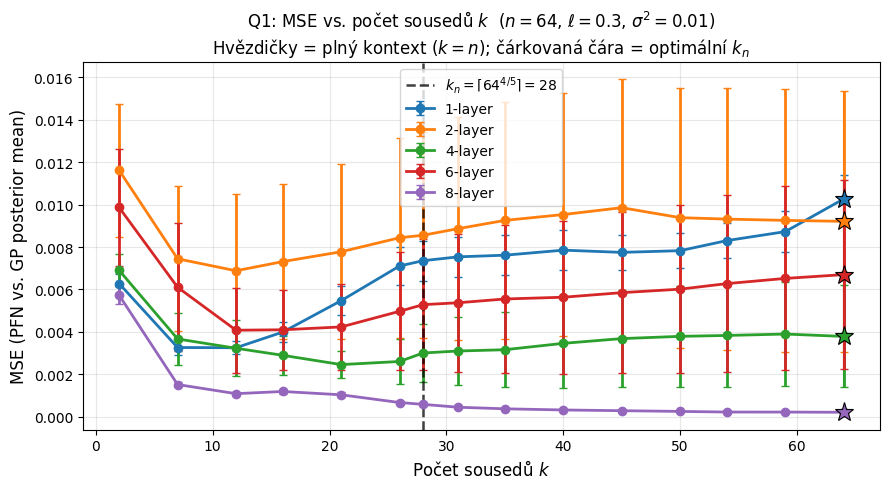


Model           MSE_full    MSE_best   Best k  Zlepšení
-------------------------------------------------------
1-layer          0.01027     0.00325       12  +68.4%
2-layer          0.00921     0.00688       12  +25.3%
4-layer          0.00378     0.00245       21  +35.1%
6-layer          0.00670     0.00407       12  +39.2%
8-layer          0.00020     0.00020       64  -0.0%


In [7]:
# =============================================
# ── OLD MODELS ── Q1: MSE vs k at fixed n
# =============================================

print(f'Computing MSE vs k for old models (n={N_FIXED})...')
q1_old = {}
for name, model in OLD_MODELS.items():
    print(f'  {name}...')
    q1_old[name] = compute_mse_vs_k(model, datasets_q1, K_VALUES, HPS, device)

# Store MSE_full of the old models for comparison in Q1 of the new models
old_models_mse_full = {name: res['full'] for name, res in q1_old.items()}

plot_mse_vs_k(q1_old, K_VALUES, N_FIXED, HPS)


Počítám MSE dekompozici pro staré modely...

--- 1-layer ---


  n=  5 (k_n=  4):  MSE_full=0.05323,  MSE_kn=0.05339


  n= 10 (k_n=  7):  MSE_full=0.05292,  MSE_kn=0.05293


  n= 20 (k_n= 11):  MSE_full=0.01858,  MSE_kn=0.01488


  n= 40 (k_n= 20):  MSE_full=0.01209,  MSE_kn=0.01041


...

  n= 20 (k_n= 11):  MSE_full=0.00114,  MSE_kn=0.00208


  n= 40 (k_n= 20):  MSE_full=0.00052,  MSE_kn=0.00069


  n= 64 (k_n= 28):  MSE_full=0.00024,  MSE_kn=0.00066


  n=100 (k_n= 40):  MSE_full=0.00010,  MSE_kn=0.00052


  n=128 (k_n= 49):  MSE_full=0.00023,  MSE_kn=0.00067


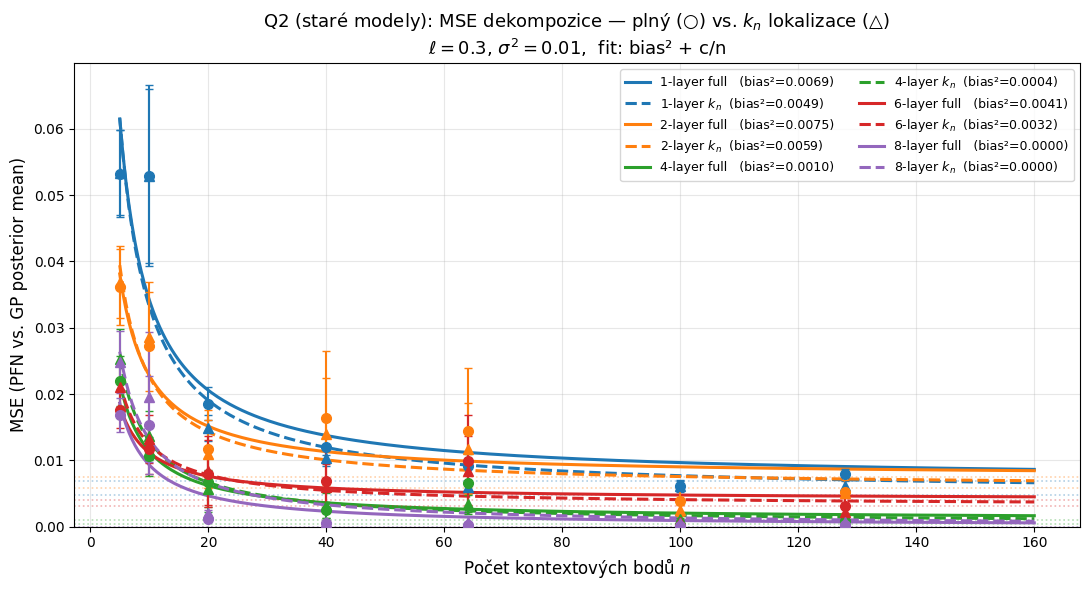


Model           bias²_full    bias²_kn  Relativní změna
--------------------------------------------------------
1-layer            0.00694     0.00486          +30.0%
2-layer            0.00749     0.00589          +21.5%
4-layer            0.00101     0.00043          +57.5%
6-layer            0.00407     0.00315          +22.5%
8-layer            0.00000     0.00000          +64.0%


In [8]:
# =============================================
# ── OLD MODELS ── Q2: MSE decomposition bias² + c/n
# =============================================

print('Computing MSE decomposition for old models...')
all_decomp_old = {}
for name, model in OLD_MODELS.items():
    print(f'\n--- {name} ---')
    all_decomp_old[name] = compute_mse_decomp_localized(model, decomp_data, HPS, device)

plot_mse_decomp_localized(all_decomp_old, HPS)




In [9]:
# =============================================
# LOAD NEW MODELS
# =============================================

NEW_MODEL_PATHS = {
    '1-layer': os.path.join('models', 'pfn_localized_rand_hps', 'pfn_gp_1Lmodel.pth'),
    '2-layer': os.path.join('models', 'pfn_localized_rand_hps', 'pfn_gp_2Lmodel.pth'),
    '4-layer': os.path.join('models', 'pfn_localized_rand_hps', 'pfn_gp_4Lmodel.pth'),
    '6-layer': os.path.join('models', 'pfn_localized_rand_hps', 'pfn_gp_6Lmodel.pth'),
    '8-layer': os.path.join('models', 'pfn_localized_rand_hps', 'pfn_gp_8Lmodel.pth'),
}

print('Loading new models...')
NEW_MODELS = {}
for name, path in NEW_MODEL_PATHS.items():
    if os.path.exists(path):
        NEW_MODELS[name], _ = load_for_inference(path, device)
    else:
        print(f'  ⚠ Not found: {path}')

print(f'\n✓ Loaded {len(NEW_MODELS)} new models: {list(NEW_MODELS.keys())}')


Načítám nové modely...
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps

-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.07s | mean loss  1.58 | lr 0.0 | data time  0.00 step time  0.05 forward time  0.02 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
  ✓ pfn_gp_1Lmodel.pth: nlayers=1, epoch=?, 3.7M params
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_test_ins

-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.06s | mean loss  1.36 | lr 0.0 | data time  0.00 step time  0.04 forward time  0.01 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
  ✓ pfn_gp_2Lmodel.pth: nlayers=2, epoch=?, 5.7M params
init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_test_ins

-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.10s | mean loss  1.49 | lr 0.0 | data time  0.00 step time  0.08 forward time  0.02 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------
  ✓ pfn_gp_4Lmodel.pth: nlayers=4, epoch=?, 9.9M params


init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_samp

  ✓ pfn_gp_6Lmodel.pth: nlayers=6, epoch=?, 14.1M params


init dist
Not using distributed
ALL: Using device mps.
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_sampler_function': <bound method BatchShapeSamplerConfig.sample_batch_shape of BatchShapeSamplerConfig(batch_size=2, min_single_eval_pos=0, max_seq_len=128, min_num_features=1, max_num_features=1, fixed_num_test_instances=None, seed=42)>, 'num_workers': 0, 'persistent_workers': True, 'get_batch_kwargs': {'device': 'mps', 'n_targets_per_input': 1}, 'epoch_count': 0, 'importance_sampling_infos': None}
DataLoader.__dict__ {'get_batch_method': functools.partial(get_batch_sequence(
	<__main__.get_batch_for_gp_random_hps (batch_size, seq_len, num_features, device='cpu', hyperparameters=None, **kwargs)
), num_features=1, hyperparameters={}), 'num_steps': 1, 'batch_shape_samp

-----------------------------------------------------------------------------------------
| end of epoch   1 | time:  0.11s | mean loss  1.66 | lr 0.0 | data time  0.00 step time  0.09 forward time  0.03 | max gpu mem N/A GiB | gpu utilization N/A %| nan share  0.00 ignore share (for classification tasks) 0.0000 
-----------------------------------------------------------------------------------------


  ✓ pfn_gp_8Lmodel.pth: nlayers=8, epoch=?, 18.3M params

✓ Načteno 5 nových modelů: ['1-layer', '2-layer', '4-layer', '6-layer', '8-layer']


Počítám MSE_full pro nové modely (n=64)...


  1-layer: MSE_full = 1.18361


  2-layer: MSE_full = 0.71682


  4-layer: MSE_full = 1.10197


  6-layer: MSE_full = 0.00173


  8-layer: MSE_full = 1.10116


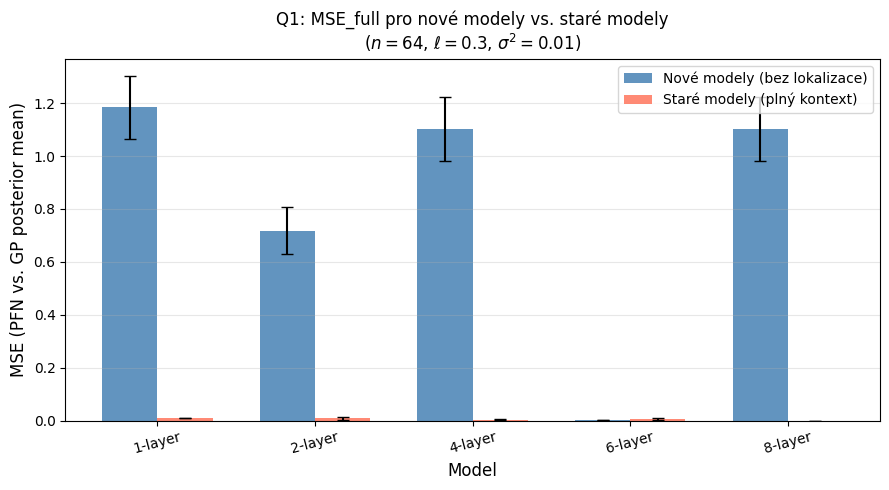


Model           MSE_nové   MSE_staré  Rozdíl
------------------------------------------------
1-layer          1.18361     0.01027  +1.17334
2-layer          0.71682     0.00921  +0.70761
4-layer          1.10197     0.00378  +1.09819
6-layer          0.00173     0.00670  -0.00496
8-layer          1.10116     0.00020  +1.10096


In [10]:
# =============================================
# ── NEW MODELS ── Q1: MSE_full per model (no localization)
# =============================================

print(f'Computing MSE_full for new models (n={N_FIXED})...')
q1_new_full = compute_mse_full_all(NEW_MODELS, datasets_q1, HPS, device)

plot_q1_new_models(q1_new_full, old_models_mse_full, N_FIXED, HPS)


Počítám MSE dekompozici pro nové modely (plný kontext)...

--- 1-layer ---


  n=  5: MSE_full=0.86824


  n= 10: MSE_full=1.09193


  n= 20: MSE_full=1.34118


  n= 40: MSE_full=1.50350


...

  n= 20: MSE_full=1.14999


  n= 40: MSE_full=1.29009


  n= 64: MSE_full=1.10680


  n=100: MSE_full=0.89254


  n=128: MSE_full=1.00684


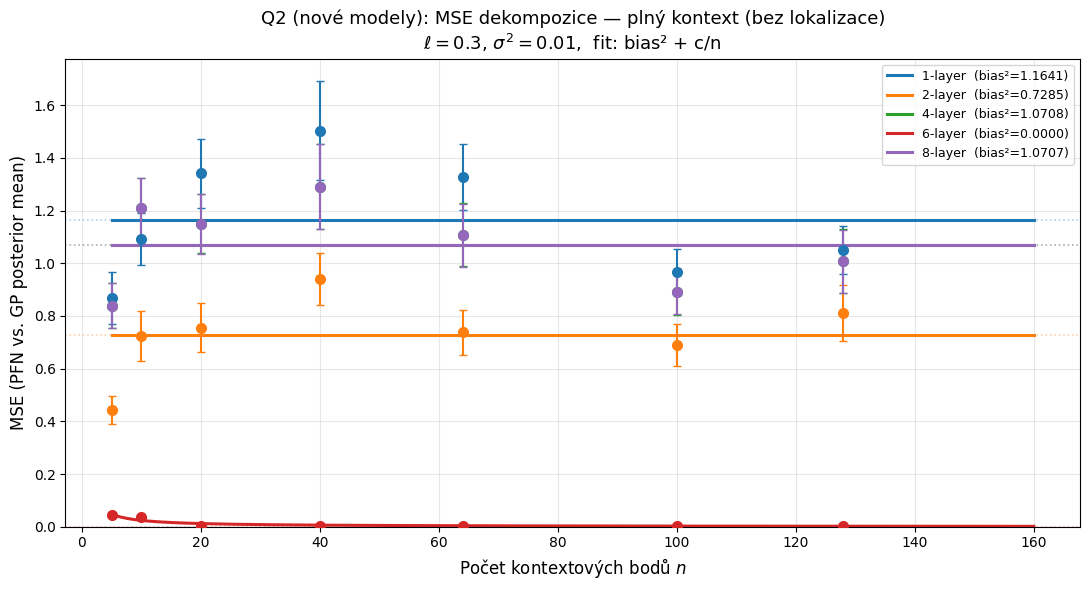


Model                bias²           c
------------------------------------
1-layer            1.16413      0.0000
2-layer            0.72851      0.0000
4-layer            1.07076      0.0000
6-layer            0.00000      0.2404
8-layer            1.07066      0.0000


In [11]:
# =============================================
# ── NEW MODELS ── Q2: MSE decomposition bias² + c/n (no localization)
# =============================================

print('Computing MSE decomposition for new models (full context)...')
all_decomp_new = {}
for name, model in NEW_MODELS.items():
    print(f'\n--- {name} ---')
    all_decomp_new[name] = compute_mse_decomp_full_only(model, decomp_data, HPS, device)

plot_mse_decomp_full_only(all_decomp_new, HPS)


## Reading the outputs

### Q1 - MSE vs k (old models)

**X axis:** number of nearest neighbours $k$  
**Y axis:** MSE(PFN_k vs GP posterior mean)  
**Stars:** standard PFN with the full context ($k = n$)  
**Dashed line:** optimal $k_n = \lceil n^{4/5} \rceil$

### Q1 - MSE_full (new models, no localization)

The bar chart shows the MSE of the new models with the full context next to the MSE of the old models with the full context.

### Q2 - MSE decomposition

**Old models:** solid line (○) = full context; dashed line (△) = $k_n$ localization  
**New models:** solid line (○) = full context (no localization)

Each curve is fitted with $\text{bias}^2 + c/n$; the fitted bias² is reported in the legend and printed in the table.

### Nagler (2023) - theory

For $k_n = \lceil n^{4/(d+4)} \rceil$:
- $k_n \to \infty$: the localized estimator converges to the truth
- $k_n / n \to 0$: the fraction of points used decreases (for 1D: $n^{-1/5} \to 0$)
- The bias² of the localized estimator $\to 0$ as $n \to \infty$
